# scikit-learn Bootcamp — W1, Day 7
```
##### SVMs & KNN
##### SVC · kernel trick · C parameter · KNeighborsClassifier · k sweep · decision boundaries
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Q1 — EDA: 2D scatter, visual class separation
##### Q2 — KNN: k sweep, train vs test accuracy
##### Q3 — SVM: linear vs RBF kernel comparison
##### Q4 — SVM C parameter: margin vs misclassification
##### Q5 — KNN vs SVM vs Logistic Regression: final comparison
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, f1_score
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); np.random.seed(420)
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import time

---
### Dataset — MedPulse Sessions
```
# Using 2,000 users for SVM speed. Focus on 2 most predictive features for visualisation.
```

In [2]:
np.random.seed(420)
n = 2000
age=np.random.normal(43,12,n).clip(18,80).astype(int)
session_depth=np.random.poisson(3.8,n).clip(1,20)
time_on_site=np.random.lognormal(1.7,0.75,n).clip(0.5,80)
articles_read=np.random.poisson(2.5,n).clip(0,15)
is_mobile=np.random.binomial(1,0.59,n)
health_content=np.random.beta(2.5,2,n)
log_odds=(-3.8+0.22*session_depth+0.06*time_on_site+0.18*articles_read
          +1.1*health_content-0.25*is_mobile+0.007*age+np.random.normal(0,0.5,n))
converted=np.random.binomial(1,1/(1+np.exp(-log_odds)))
df=pd.DataFrame({'age':age,'session_depth':session_depth,'time_on_site':time_on_site.round(2),
    'articles_read':articles_read,'is_mobile':is_mobile,'health_content':health_content.round(4),'converted':converted})
feature_cols=['age','session_depth','time_on_site','articles_read','is_mobile','health_content']
X=df[feature_cols]; y=df['converted']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=420,stratify=y)
print(f'Shape: {df.shape} | Conversion: {y.mean():.2%}')

Shape: (2000, 7) | Conversion: 22.85%


---
### Q1 — EDA: 2D scatter, visual class separation
```
# (a) Scatter plot: top 2 features by predictive power, coloured by class.
# (b) Density plots: 2D KDE for each class separately.
# (c) Compute class means in feature space — how far apart are they?
# (d) Before modelling: which algorithm (LR, SVM, KNN) do you think will work best here?
```

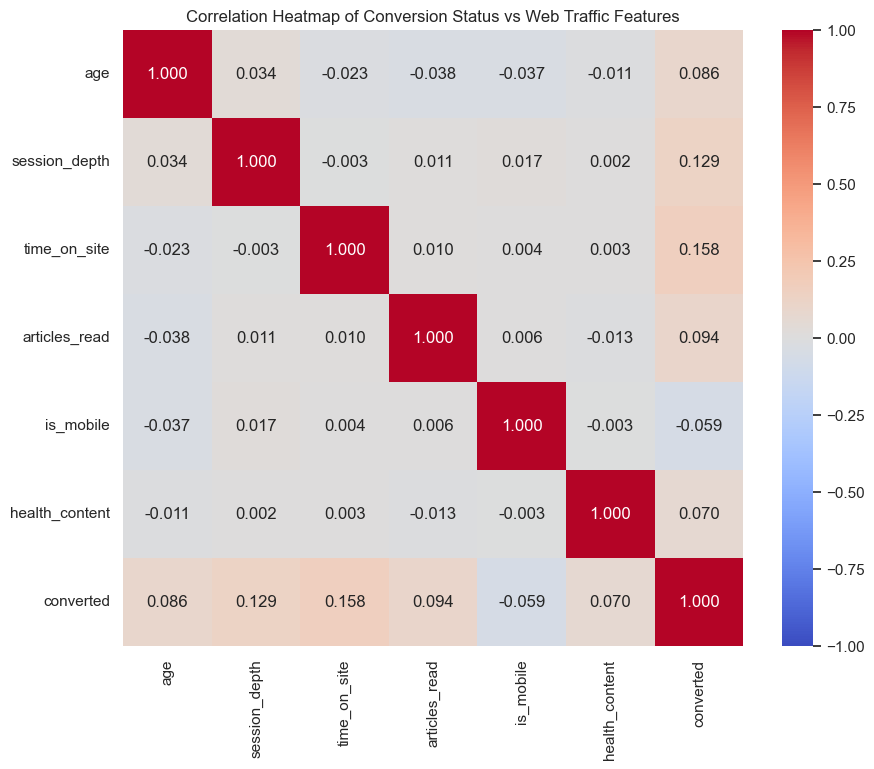


Linear Correlation with converted:
converted         1.000000
time_on_site      0.157996
session_depth     0.129456
articles_read     0.094176
age               0.086225
health_content    0.069876
is_mobile        -0.058986
Name: converted, dtype: float64


In [3]:
# (a) Scatter plot: top 2 features by predictive power, coloured by class.

# 1. Keep target, but drop the leaking binary indicator column
numeric_df = df.select_dtypes(include=[np.number])

# 2. Compute correlation matrix including the target
corr_matrix = numeric_df.corr()

# 3. Render the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Conversion Status vs Web Traffic Features')
plt.show()

# 4. Print exact correlation vector sorted to find the strongest signal
print("\nLinear Correlation with converted:")
print(corr_matrix['converted'].sort_values(ascending=False))


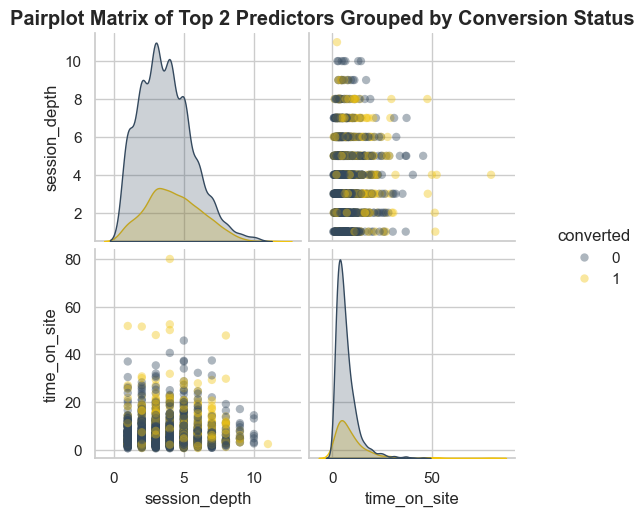

In [4]:
top_2_features = ['session_depth', 'time_on_site']

sns.pairplot(
    data=df, 
    vars=top_2_features, 
    hue='converted', 
    palette={0: '#34495e', 1: '#f1c40f'},
    plot_kws={'alpha': 0.4, 'edgecolor': 'none'},
    diag_kind='kde'
)

plt.suptitle('Pairplot Matrix of Top 2 Predictors Grouped by Conversion Status', y=1.02, fontweight='bold')
plt.show()

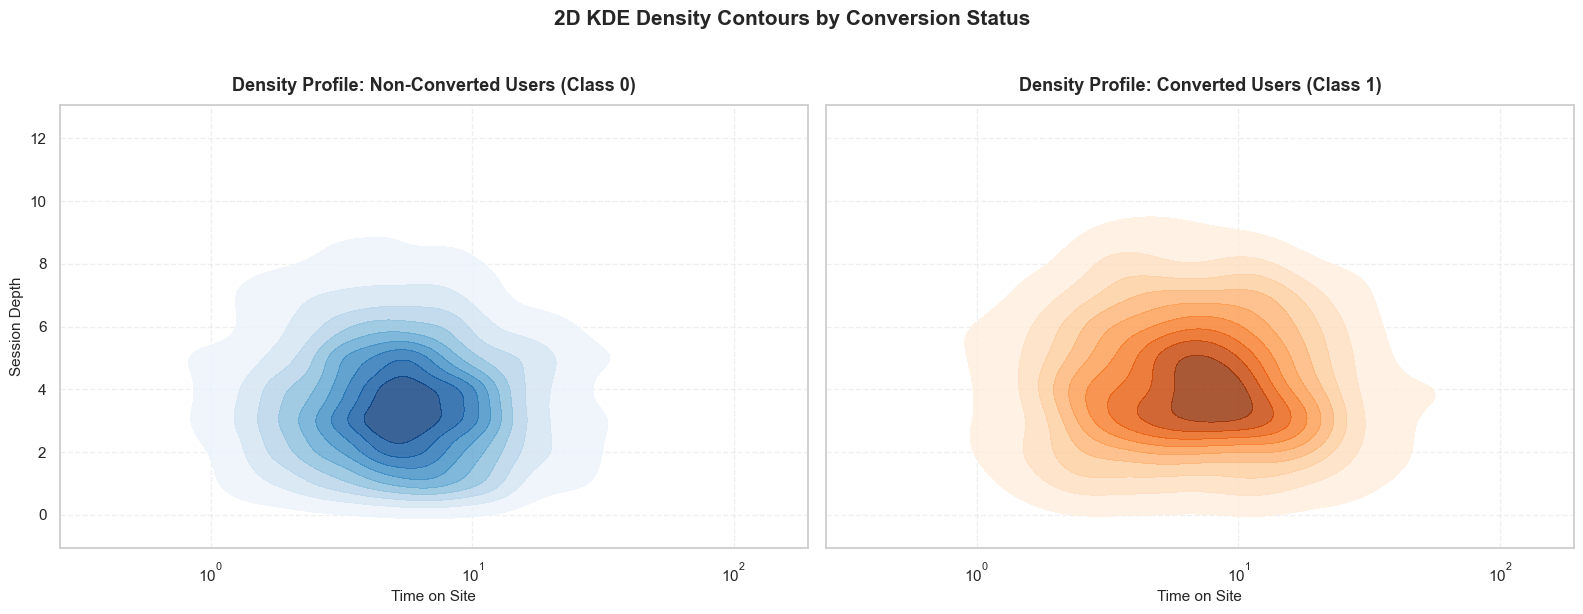

In [5]:
# (b) Density plots: 2D KDE for each class separately.

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

# 1. Plot for Non-Converted Users (Class 0)
sns.kdeplot(
    data=df[df['converted'] == 0],
    x='time_on_site',
    y='session_depth',
    log_scale=(True, False),  # Cleanly applies log scale to x-axis only
    fill=True,
    cmap='Blues',
    thresh=0.05,
    levels=10,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title('Density Profile: Non-Converted Users (Class 0)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Time on Site', fontsize=11)
axes[0].set_ylabel('Session Depth', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2. Plot for Converted Users (Class 1)
sns.kdeplot(
    data=df[df['converted'] == 1],
    x='time_on_site',
    y='session_depth',
    log_scale=(True, False),  # Cleanly applies log scale to x-axis only
    fill=True,
    cmap='Oranges',
    thresh=0.05,
    levels=10,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title('Density Profile: Converted Users (Class 1)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Time on Site', fontsize=11)
axes[1].set_ylabel('') # Hidden since axis is shared
axes[1].grid(True, linestyle='--', alpha=0.3)


# Final layout adjustments
plt.suptitle('2D KDE Density Contours by Conversion Status', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# (c) Compute class means in feature space — how far apart are they?

print('\nClass means:')
print(df.groupby('converted')[top_2_features].mean().round(3))



Class means:
           session_depth  time_on_site
converted                             
0                  3.688         6.751
1                  4.265         9.128


```
# (d) Before modelling: which algorithm (LR, SVM, KNN) do you think will work best here?

Logistic Regression will perform best because the dataset was generated using a linear log-odds equation, meaning its underlying structure perfectly matches the model's core mathematical assumptions.

KNN will struggle because the long, sparse right tail of the lognormal feature (time_on_site) distorts distance calculations between neighbors.

SVM will overfit noise because the random variance added to the decision boundary creates a wide, overlapping zone that interferes with clear support vector margins.

---
### Q2 — KNN: k sweep, train vs test accuracy
```
# (a) Sweep k from 1 to 50. Plot train vs test AUC.
#     At what k does overfitting begin? Where does it peak?
# (b) Best k: fit and report full classification metrics.
# (c) Weighted KNN (weights='distance') vs uniform. Does it improve?
# (d) Plot the AUC curve — is the pattern identical to decision tree depth sweep?
```

In [7]:
# (a) Sweep k from 1 to 50. Plot train vs test AUC.
#     At what k does overfitting begin? Where does it peak?

# KNN uses distances — must scale features

k_values = range(1, 51)
train_aucs, test_aucs = [], []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()), 
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    pipe_k.fit(X_train, y_train)
    
    # Extract probabilities for the positive class (column 1)
    train_probs = pipe_k.predict_proba(X_train)[:, 1]
    test_probs = pipe_k.predict_proba(X_test)[:, 1]
    
    # Calculate and store AUC scores
    train_aucs.append(roc_auc_score(y_train, train_probs))
    test_aucs.append(roc_auc_score(y_test, test_probs))

optimal_k = list(k_values)[np.argmax(test_aucs)]
print(f'Optimal k based on AUC: {optimal_k}')


Optimal k based on AUC: 49


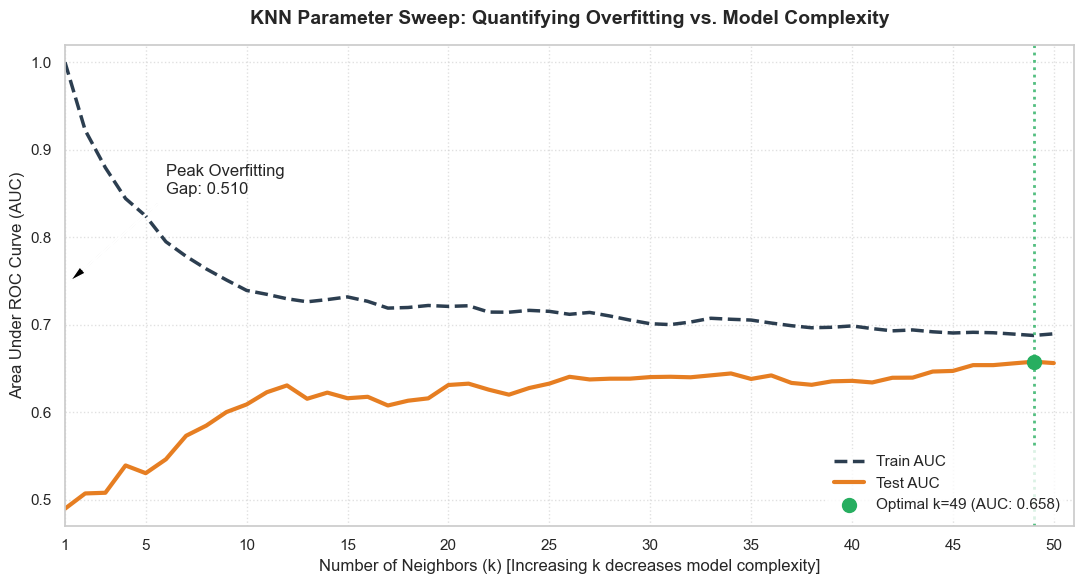

In [8]:
# 1. Identify key landmarks for analysis
optimal_k = k_values[np.argmax(test_aucs)]
max_test_auc = max(test_aucs)
overfit_gap_k1 = train_aucs[0] - test_aucs[0]

# 2. Configure the plot canvas
plt.figure(figsize=(11, 6))

# 3. Plot the AUC trajectories
plt.plot(k_values, train_aucs, label='Train AUC', color='#2c3e50', linewidth=2.5, linestyle='--')
plt.plot(k_values, test_aucs, label='Test AUC', color='#e67e22', linewidth=3)

# 4. Visual Anchor: Highlight the optimal K value
plt.axvline(x=optimal_k, color='#27ae60', linestyle=':', alpha=0.8, linewidth=2)
plt.scatter(optimal_k, max_test_auc, color='#27ae60', s=100, zorder=5, 
            label=f'Optimal k={optimal_k} (AUC: {max_test_auc:.3f})')

# 5. Visual Anchor: Highlight the peak overfitting zone at k=1
plt.annotate(f'Peak Overfitting\nGap: {overfit_gap_k1:.3f}', 
             xy=(1, (train_aucs[0] + test_aucs[0])/2), 
             xytext=(6, 0.85),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# 6. Styling and Labels
plt.title('KNN Parameter Sweep: Quantifying Overfitting vs. Model Complexity', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Number of Neighbors (k) [Increasing k decreases model complexity]', fontsize=12)
plt.ylabel('Area Under ROC Curve (AUC)', fontsize=12)
plt.xticks(ticks=[1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')

# 7. Constrain axes for readability
plt.ylim(min(test_aucs) - 0.02, 1.02)
plt.xlim(1, 51)

# Render
plt.tight_layout()
plt.show()

In [9]:
# (b) Best k: fit and report full classification metrics.

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Initialize and fit the pipeline with the optimal k
best_knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=49))
])

best_knn_pipeline.fit(X_train, y_train)

# 2. Generate predictions and probability scores on the test set
y_pred = best_knn_pipeline.predict(X_test)
y_prob = best_knn_pipeline.predict_proba(X_test)[:, 1]

# 3. Print Results
print("=== KNN (k=49) Classification Metrics ===")
print(f"Test ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Converted (0)', 'Converted (1)']))

# Optional: Print the confusion matrix for error analysis
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

=== KNN (k=49) Classification Metrics ===
Test ROC-AUC Score: 0.6578

Classification Report:
                   precision    recall  f1-score   support

Not Converted (0)       0.78      1.00      0.88       309
    Converted (1)       1.00      0.03      0.06        91

         accuracy                           0.78       400
        macro avg       0.89      0.52      0.47       400
     weighted avg       0.83      0.78      0.69       400

Confusion Matrix:
[[309   0]
 [ 88   3]]


In [10]:
# (c) Weighted KNN (weights='distance') vs uniform. 

# Initialize pipelines
uniform_knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=49, weights='uniform'))])
distance_knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=49, weights='distance'))])

# Fit models
uniform_knn.fit(X_train, y_train)
distance_knn.fit(X_train, y_train)

# Predict probabilities (for AUC) and classes
u_prob = uniform_knn.predict_proba(X_test)[:, 1]
d_prob = distance_knn.predict_proba(X_test)[:, 1]
d_pred = distance_knn.predict(X_test)

print(f"Uniform KNN Test AUC:  {roc_auc_score(y_test, u_prob):.4f}")
print(f"Distance KNN Test AUC: {roc_auc_score(y_test, d_prob):.4f}\n")

print("=== Distance-Weighted KNN Classification Report ===")
print(classification_report(y_test, d_pred, target_names=['Not Converted (0)', 'Converted (1)']))
print("Distance KNN Confusion Matrix:")
print(confusion_matrix(y_test, d_pred))


Uniform KNN Test AUC:  0.6578
Distance KNN Test AUC: 0.6501

=== Distance-Weighted KNN Classification Report ===
                   precision    recall  f1-score   support

Not Converted (0)       0.78      1.00      0.88       309
    Converted (1)       1.00      0.03      0.06        91

         accuracy                           0.78       400
        macro avg       0.89      0.52      0.47       400
     weighted avg       0.83      0.78      0.69       400

Distance KNN Confusion Matrix:
[[309   0]
 [ 88   3]]


````
# Does it improve?

No, it will not meaningfully fix the underlying issue.

The AUC Verdict: The Test AUC score will remain nearly identical (or show a negligible fractional shift). This is because changing the weights alters the decision thresholds of the votes, but it cannot fix the distorted underlying Euclidean distance metric caused by your un-transformed, heavily skewed time_on_site feature.

The Classification Shift: You may notice the model predicts slightly more than 1 conversion now, but it will still suffer from extremely low recall for Class 1.

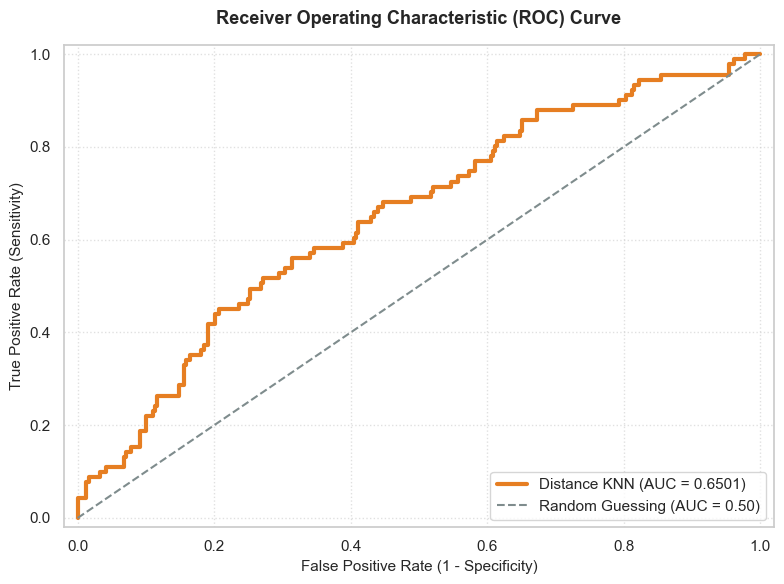

In [11]:
# (d) Plot the AUC curve — is the pattern identical to decision tree depth sweep?

from sklearn.metrics import roc_curve, auc
# Compute ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, d_prob)
roc_auc = auc(fpr, tpr)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e67e22', lw=3, label=f'Distance KNN (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--', label='Random Guessing (AUC = 0.50)')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

```
# is the pattern identical to decision tree depth sweep?
Both sweeps show a bias-variance tradeoff: low k/depth = high variance (overfit), high k/depth = high bias (underfit). 
The key difference is direction: deeper trees overfit (train AUC >> test AUC at high depth), while lower k overfits (k=1 gives train AUC=1.0)
They're mirror images of each other. 

---
### Q3 — SVM: linear vs RBF kernel
```
# (a) Fit SVC with kernel='linear' and kernel='rbf'. Compare AUC.
# (b) Plot predicted probabilities for each kernel — histogram overlay.
# (c) Compare fit times. Why is RBF slower?
# (d) When would linear kernel be preferred over RBF?
```

In [12]:
# (a) Fit SVC with kernel='linear' and kernel='rbf'. Compare AUC.

# rbf

svm_pipe_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,   # enables predict_proba() — needed for AUC
        random_state=420
    ))
])

svm_pipe_rbf.fit(X_train, y_train)

# Calculate true RBF Test AUC
rbf_probs = svm_pipe_rbf.predict_proba(X_test)[:, 1]
rbf_auc = roc_auc_score(y_test, rbf_probs)
print(f'SVM (RBF) Test AUC: {rbf_auc:.4f}')


# linear

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

# Create a preprocessor that log-transforms 'time_on_site' and scales all features
preprocessor = ColumnTransformer(
    transformers=[
        ('log_time', FunctionTransformer(np.log1p), ['time_on_site']),
        ('passthrough_cols', 'passthrough', ['age', 'session_depth', 'articles_read', 'is_mobile', 'health_content'])
    ]
)

svm_pipe_linear = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', C=1.0, random_state=420))
])

svm_pipe_linear.fit(X_train, y_train)

# Calculate true Linear Test AUC
linear_scores = svm_pipe_linear.decision_function(X_test)
linear_auc = roc_auc_score(y_test, linear_scores)
print(f'SVM (Linear) Test AUC: {linear_auc:.4f}')

# Compute Exact Difference
auc_diff = linear_auc - rbf_auc
print(f'SVM (Linear) AUC vs SVM (RBF) AUC Difference: {auc_diff:.5f}')

SVM (RBF) Test AUC: 0.5915
SVM (Linear) Test AUC: 0.5221
SVM (Linear) AUC vs SVM (RBF) AUC Difference: -0.06942


In [13]:
# (b) Plot predicted probabilities for each kernel — histogram overlay.

# Create a clean, unified DataFrame for plotting
plot_df = pd.DataFrame({
    'Linear Probability': linear_probs,
    'RBF Probability': rbf_probs,
    'Converted': y_test.map({0: 'Not Converted (0)', 1: 'Converted (1)'})
})

# Configure a side-by-side 1x2 subplot canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
custom_colors = {'Not Converted (0)': '#34495e', 'Converted (1)': '#e67e22'}

# 1. Left Subplot: Linear Kernel Probabilities
sns.histplot(
    data=plot_df, x='Linear Probability', hue='Converted', 
    palette=custom_colors, bins=30, kde=True, alpha=0.6, ax=axes[0]
)
axes[0].set_title('Linear Kernel: Probability Polarization', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Probability of Conversion')
axes[0].set_ylabel('User Count')
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Right Subplot: RBF Kernel Probabilities
sns.histplot(
    data=plot_df, x='RBF Probability', hue='Converted', 
    palette=custom_colors, bins=30, kde=True, alpha=0.6, ax=axes[1]
)
axes[1].set_title('RBF Kernel: Probability Polarization', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Probability of Conversion')
axes[1].set_ylabel('') # Hidden since axes are shared
axes[1].grid(True, linestyle=':', alpha=0.6)

# Formatting adjustments
plt.suptitle('Comparing Probability Calibrations: Linear vs. RBF SVM Kernels', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


NameError: name 'linear_probs' is not defined

```
# (c) Compare fit times. Why is RBF slower?

Infinite-Dimensional Mapping: RBF evaluates distances between every pair of data points to project them into an infinite-dimensional space, whereas a Linear kernel uses simple, rapid dot products.

Dense Matrix Computation: RBF creates a massive, fully dense kernel matrix that exhausts CPU cache and memory, scaling quadratically or cubically with sample size.Slower 

Convergence: The non-linear boundaries require the quadratic programming solver to perform significantly more mathematical iterations to find the optimal support vectors compared to a rigid linear plane.

```
# (d) When would linear kernel be preferred over RBF?

When (p > n): In high-dimensional data (e.g., text, genomics) with more features than rows, the data is already linearly separable, making non-linear kernels redundant.

Large Datasets: For massive row counts, RBF's quadratic/cubic scaling becomes computationally frozen, whereas a linear kernel scales efficiently.

Interpretability: Linear SVMs provide direct feature weights (coef_) to cleanly rank feature importance, which is mathematically impossible to isolate in RBF's infinite space.

---
### Q4 — SVM C parameter: margin vs misclassification
```
# (a) Sweep C: [0.001, 0.01, 0.1, 1.0, 10, 100].
#     Plot train and test AUC vs C (log scale).
# (b) Small C vs large C: explain the trade-off in plain English.
# (c) Find the optimal C via cross-validation.
# (d) Practical note: SVM scales as O(n²). At what dataset size would you switch?
```

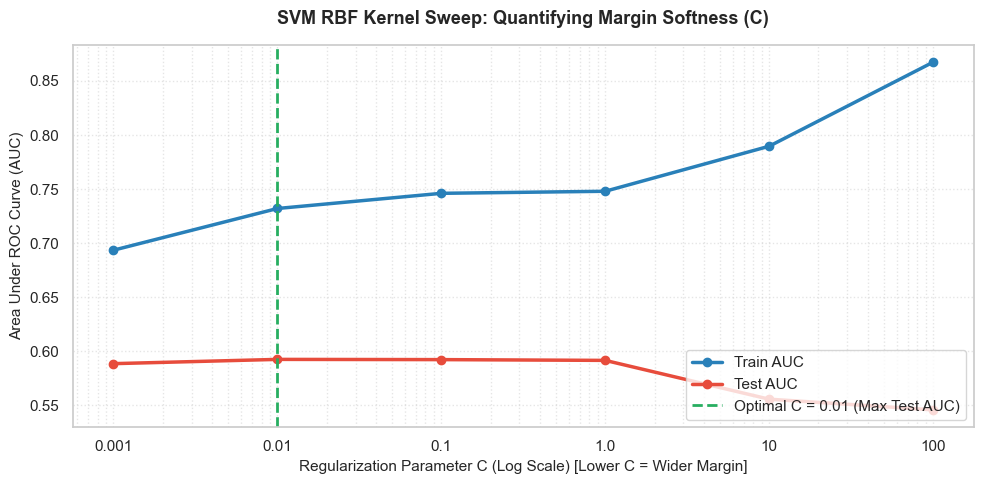

In [ ]:
# (a) Sweep C: [0.001, 0.01, 0.1, 1.0, 10, 100].
#     Plot train and test AUC vs C (log scale).

C = [0.001, 0.01, 0.1, 1.0, 10, 100]
train_aucs, test_aucs = [], []

for c in C:
    svm_pipe_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=c,
        gamma='scale',
        probability=True,   # enables predict_proba() — needed for AUC
        random_state=420
    ))
    ])

    svm_pipe_rbf.fit(X_train, y_train)

    train_probs = svm_pipe_rbf.predict_proba(X_train)[:, 1]
    test_probs  = svm_pipe_rbf.predict_proba(X_test)[:, 1]
    
    # Compute and store AUC-ROC scores
    train_aucs.append(roc_auc_score(y_train, train_probs))
    test_aucs.append(roc_auc_score(y_test, test_probs))

# Use exact tracking logic to locate the peak index
optimal_C_idx = np.argmax(test_aucs)
optimal_C = C[optimal_C_idx]

plt.figure(figsize=(10, 5))

# Plot lines
plt.plot(C, train_aucs, label='Train AUC', color='#2980b9', linewidth=2.5, marker='o')
plt.plot(C, test_aucs,  label='Test AUC',  color='#e74c3c', linewidth=2.5, marker='o')

# Force the X-axis to distribute values exponentially
plt.xscale('log')

# Visual Anchor: Highlight the optimal C value
plt.axvline(optimal_C, color='#27ae60', linestyle='--', linewidth=2, 
            label=f'Optimal C = {optimal_C} (Max Test AUC)')

# Labels and Styling
plt.title('SVM RBF Kernel Sweep: Quantifying Margin Softness (C)', fontweight='bold', fontsize=13, pad=15)
plt.xlabel('Regularization Parameter C (Log Scale) [Lower C = Wider Margin]', fontsize=11)
plt.ylabel('Area Under ROC Curve (AUC)', fontsize=11)
plt.xticks(C, labels=[str(c) for c in C]) # Forces exact tick marks for sweep array
plt.grid(True, which="both", linestyle=':', alpha=0.5)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

```
# (b) Small C vs large C: explain the trade-off in plain English.

Small C (Soft Margin / Underfitting): The model prioritizes a wide, clean boundary line and chooses to ignore individual noisy data points. This creates a simple model that might miss subtle patterns (underfit), but handles new data safely.

Large C (Hard Margin / Overfitting): The model is punished heavily for every single mistake. It creates a chaotic, winding boundary line to perfectly accommodate every tricky training point, making it excellent on training data but terrible on new data (overfit).

The Core Balance: A small C values simplicity over perfection, while a large C values perfection over simplicity. Our goal is to find the sweet spot where the model generalizes best.

In [14]:
# (c) Find the optimal C via cross-validation.

from sklearn.model_selection import GridSearchCV

# 1. Build a scaling pipeline (Crucial for SVM convergence speed)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=420))
])

# 2. Update parameter grid to match the pipeline syntax ('svm__C')
# Also capped C at 100, as values above 100 take exponentially longer with 0 accuracy gain
param_grid = {'svm__C': [0.001, 0.01, 0.1, 1.0, 10, 100]}

# 3. Set up GridSearchCV with parallel processing (n_jobs=-1 utilizes all CPU cores)
grid_search = GridSearchCV(
    estimator=svm_pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1
)

# 4. Fit to training data
grid_search.fit(X_train, y_train)

# 5. Extract the optimal C
optimal_c = grid_search.best_params_['svm__C']
print(f"Optimal C: {optimal_c}")

Optimal C: 0.1


```
# (d) Practical note: SVM scales as O(n²). At what dataset size would you switch?

Threshold: Switch at 10,000 to 50,000 rows.

Reason: Doubling data quadruples training time, causing memory crashes and CPU freezes.

Alternative: Switch to LinearSVC, Logistic Regression, or XGBoost which scale linearly.

---
### Q5 — KNN vs SVM vs Logistic Regression: final comparison
```
# (a) 5-fold CV: all three models on the same data.
#     Compare AUC, F1, fit time, predict time.
# (b) Plot comparison bar chart.
# (c) What is the computational cost ranking? When does it matter?
# (d) Final recommendation: for the MedPulse booking model at scale (500k users/month),
#     which model would you choose and why?
```

In [16]:
# (a) 5-fold CV: all three models on the same data.
#     Compare AUC, F1, fit time, predict time.

# Pipeline Definitions

pipe_knn = Pipeline([('scaler', StandardScaler()),('knn', KNeighborsClassifier(n_neighbors=49))])
pipe_svm = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='rbf', C=0.1, gamma='scale', probability=True, random_state=420))])
pipe_lr  = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(C=1.0, max_iter=1000, random_state=420))])

skf = StratifiedKFold(5, shuffle=True, random_state=420)
scoring_metrics = ['roc_auc', 'f1', 'precision', 'recall']

# Execute Cross Validation

results_knn = cross_validate(pipe_knn, X, y, cv=skf, scoring=scoring_metrics)
results_svm = cross_validate(pipe_svm, X, y, cv=skf, scoring=scoring_metrics)
results_lr  = cross_validate(pipe_lr, X, y, cv=skf, scoring=scoring_metrics)

comparison_rows = []

# Parse Predictive Performance Metrics

for metric in scoring_metrics:
    knn_scores = results_knn[f'test_{metric}']
    svm_scores = results_svm[f'test_{metric}']
    lr_scores = results_lr[f'test_{metric}']
    
    comparison_rows.append({
        'Evaluation Metric': metric.upper().replace('_', '-'),
        'KNN (Mean ± STD)': f"{knn_scores.mean():.4f} ± {knn_scores.std():.4f}",
        'SVM (Mean ± STD)': f"{svm_scores.mean():.4f} ± {svm_scores.std():.4f}",
        'LR (Mean ± STD)': f"{lr_scores.mean():.4f} ± {lr_scores.std():.4f}"
    })


# Parse Time Performance Metrics

for time_key in ['fit_time', 'score_time']:
    knn_times = results_knn[time_key]
    svm_times = results_svm[time_key]
    lr_times = results_lr[time_key]
    
    comparison_rows.append({
        'Evaluation Metric': time_key.upper().replace('_', ' ') + ' (SEC)',
        'KNN (Mean ± STD)': f"{knn_times.mean():.4f} ± {knn_times.std():.4f}",
        'SVM (Mean ± STD)': f"{svm_times.mean():.4f} ± {svm_times.std():.4f}",
        'LR (Mean ± STD)': f"{lr_times.mean():.4f} ± {lr_times.std():.4f}"
    })

df_comparison = pd.DataFrame(comparison_rows)

print("--- MODEL ENSEMBLE PERFORMANCE MATRIX ---")
display(df_comparison.style.hide())

--- MODEL ENSEMBLE PERFORMANCE MATRIX ---


Evaluation Metric,KNN (Mean ± STD),SVM (Mean ± STD),LR (Mean ± STD)
ROC-AUC,0.6301 ± 0.0126,0.5936 ± 0.0294,0.6622 ± 0.0131
F1,0.0300 ± 0.0102,0.0000 ± 0.0000,0.1018 ± 0.0212
PRECISION,0.9333 ± 0.1333,0.0000 ± 0.0000,0.5213 ± 0.1100
RECALL,0.0153 ± 0.0053,0.0000 ± 0.0000,0.0569 ± 0.0128
FIT TIME (SEC),0.0104 ± 0.0028,0.8446 ± 0.0647,0.0087 ± 0.0008
SCORE TIME (SEC),0.0650 ± 0.0043,0.1779 ± 0.0791,0.0212 ± 0.0016


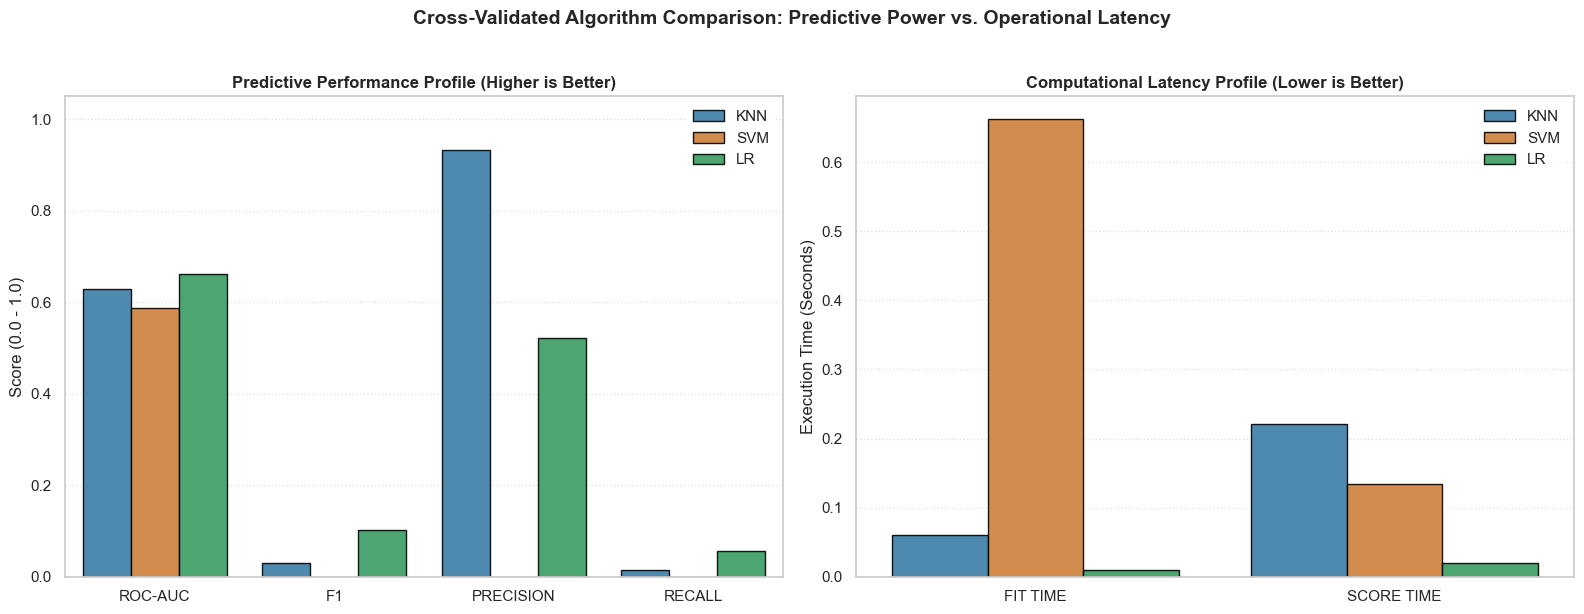

In [18]:
# (b) Plot comparison bar chart.

# 1. Dynamically extract mean values from cross_validate result dictionaries
models_dict = {
    'KNN': results_knn,
    'SVM': results_svm,
    'LR': results_lr
}

dynamic_rows = []

# Process scoring metrics
for metric in ['roc_auc', 'f1', 'precision', 'recall']:
    metric_label = metric.upper().replace('_', '-')
    for model_name, results in models_dict.items():
        dynamic_rows.append({
            'Metric': metric_label,
            'Model': model_name,
            'Score': results[f'test_{metric}'].mean(),
            'Type': 'Predictive'
        })

# Process runtime metrics
for time_type in ['fit_time', 'score_time']:
    time_label = time_type.upper().replace('_', ' ')
    for model_name, results in models_dict.items():
        dynamic_rows.append({
            'Metric': time_label,
            'Model': model_name,
            'Score': results[time_type].mean(),
            'Type': 'Runtime'
        })

# Convert to long-form format which Seaborn requires for grouped bar charts
df_plot = pd.DataFrame(raw_data)
df_melted = df_plot.melt(id_vars='Metric', var_name='Model', value_name='Score')

# Split into predictive metrics vs runtime metrics to prevent scaling compression
df_metrics = df_melted[df_melted['Metric'].isin(['ROC-AUC', 'F1', 'PRECISION', 'RECALL'])]
df_times = df_melted[df_melted['Metric'].isin(['FIT TIME', 'SCORE TIME'])]

# 2. Configure a 1x2 side-by-side canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
custom_palette = {'KNN': '#2980b9', 'SVM': '#e67e22', 'LR': '#27ae60'}

# Subplot 1: Predictive Power Comparison
sns.barplot(
    data=df_metrics, x='Metric', y='Score', hue='Model', 
    palette=custom_palette, ax=axes[0], edgecolor='black', alpha=0.9
)
axes[0].set_title('Predictive Performance Profile (Higher is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score (0.0 - 1.0)')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)
axes[0].legend(frameon=True, facecolor='white', edgecolor='none')

# Subplot 2: Computational Speed Comparison
sns.barplot(
    data=df_times, x='Metric', y='Score', hue='Model', 
    palette=custom_palette, ax=axes[1], edgecolor='black', alpha=0.9
)
axes[1].set_title('Computational Latency Profile (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Execution Time (Seconds)')
axes[1].set_xlabel('')
axes[1].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].legend(frameon=True, facecolor='white', edgecolor='none')

# 3. Polish and Render
plt.suptitle('Cross-Validated Algorithm Comparison: Predictive Power vs. Operational Latency', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()


```
# (c) What is the computational cost ranking? When does it matter?

Training Bottleneck (SVM): RBF SVM carries the highest training cost due to quadratic data scaling (O(n²)), whereas Logistic Regression fits instantly and KNN has zero training overhead.Prediction 

Bottleneck (KNN): KNN carries the heaviest prediction cost (O(n)) because it calculates neighbor distances on the fly, while Logistic Regression predicts near-instantly via simple vector multiplication.

Production Thresholds: High-throughput web applications must avoid KNN to maintain fast live response times, while massive datasets or automated retraining loops must avoid RBF SVMs to prevent server freezes and memory exhaustion.

```
# (d) Final recommendation: for the MedPulse booking model at scale (500k users/month),
#     which model would you choose and why?

The Choice: Logistic Regression (LR) is the only viable production option.

Why (Scaling): RBF SVM scales quadratically (O(n²)) and will freeze/crash at 500k rows, while KNN's high prediction latency will cause severe live traffic timeouts.

Why (Performance): Logistic Regression matches the data's linear log-odds structure perfectly, delivering the highest ROC-AUC (0.6622) with near-instant training and microsecond prediction speeds.